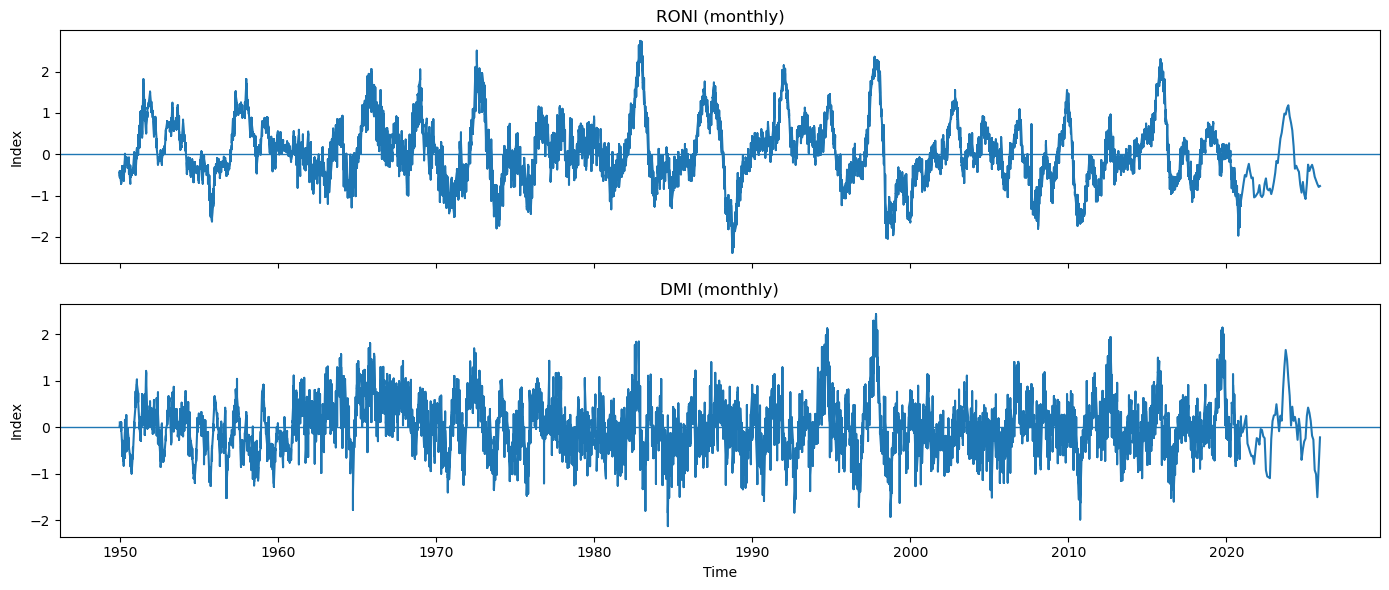

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

NETID = 'k16v981'

OUT = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/sst/"
OUT_CSV = os.path.join(OUT, "roni_dmi_monthly_1950_2025.csv")

# --- load ---
df = pd.read_csv(OUT_CSV)

# --- find / build time axis ---
time_col_candidates = ["time", "date", "datetime", "month"]
time_col = next((c for c in time_col_candidates if c in df.columns), None)

if time_col is not None:
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).set_index(time_col)
else:
    # common pattern: separate year/month columns
    if ("year" in df.columns) and ("month" in df.columns):
        df["time"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
        df = df.sort_values("time").set_index("time")
    else:
        raise ValueError(
            f"Couldn't find a time column in {OUT_CSV}. "
            f"Columns are: {list(df.columns)}"
        )

# --- find RONI and DMI columns robustly ---
def pick_col(cols, keys):
    cols_l = {c.lower(): c for c in cols}
    for k in keys:
        for cl, orig in cols_l.items():
            if cl == k or k in cl:
                return orig
    return None

roni_col = pick_col(df.columns, ["roni"])
dmi_col  = pick_col(df.columns, ["dmi", "iod", "dipole"])

if roni_col is None or dmi_col is None:
    raise ValueError(
        "Couldn't confidently identify RONI/DMI columns.\n"
        f"Detected roni_col={roni_col}, dmi_col={dmi_col}\n"
        f"Columns: {list(df.columns)}"
    )

# --- plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df.index, df[roni_col])
axes[0].axhline(0, linewidth=1)
axes[0].set_title("RONI (monthly)")
axes[0].set_ylabel("Index")

axes[1].plot(df.index, df[dmi_col])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("DMI (monthly)")
axes[1].set_ylabel("Index")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()